# Umbralizacion global, Otsu y adaptive threshold

En este cuaderno vas a comparar tres maneras de construir una mascara binaria a partir de una imagen en escala de grises. La idea no es memorizar funciones, sino entender que tipo de problema resuelve cada enfoque y cuando deja de resultar conveniente.

## Objetivo

Comparar umbralizacion global manual, `Otsu` y `adaptiveThreshold`, y reconocer como cambia la mascara cuando hay ruido o iluminacion desigual.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- explicar que hace un umbral global y que decision obliga a tomar;
- interpretar por que `Otsu` puede elegir un corte util sin fijarlo a mano;
- reconocer cuando `adaptiveThreshold` resulta mas pertinente;
- relacionar suavizado, binarizacion y preparacion de una mascara para limpieza posterior.

## Relacion con la secuencia

Este cuaderno se ubica despues de `006b - filtros de suavizado y reduccion de ruido.ipynb` y antes de `006c - morfologia matematica para limpieza de mascaras.ipynb`. Primero decidimos como binarizar; despues, si hace falta, limpiamos la mascara resultante.


## Modulos que vamos a usar

- `pathlib.Path`: para ubicar la imagen de trabajo.
- `cv2`: para leer imagenes, suavizar y umbralizar.
- `numpy`: para construir una version con iluminacion despareja.
- `matplotlib.pyplot`: para comparar resultados e histogramas.


In [ ]:
# Importamos herramientas de rutas para ubicar la imagen de trabajo.
from pathlib import Path

# Importamos OpenCV para leer la imagen y aplicar umbralizacion.
import cv2

# Importamos NumPy para construir una iluminacion artificialmente desigual.
import numpy as np

# Importamos Matplotlib para visualizar resultados dentro del cuaderno.
import matplotlib.pyplot as plt


In [ ]:
def mostrar_imagen_gris(imagen_gris, titulo):
    """Muestra una sola imagen en escala de grises."""
    # Creamos una figura simple para la imagen.
    plt.figure(figsize=(7, 6), constrained_layout=True)

    # Dibujamos la imagen y agregamos un titulo descriptivo.
    plt.imshow(imagen_gris, cmap="gray")
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    """Dibuja el histograma de intensidades de una imagen en grises."""
    # Calculamos el histograma con NumPy.
    histograma, bordes = np.histogram(imagen_gris.flatten(), bins=256, range=[0, 256])

    # Dibujamos la curva de intensidades.
    plt.figure(figsize=(10, 4), constrained_layout=True)
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de pixeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_cuatro_imagenes(imagen_1, titulo_1, imagen_2, titulo_2, imagen_3, titulo_3, imagen_4, titulo_4):
    """Muestra cuatro imagenes en una grilla de dos por dos."""
    # Creamos la grilla general.
    figura, ejes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

    # Mostramos la primera imagen.
    ejes[0, 0].imshow(imagen_1, cmap="gray")
    ejes[0, 0].set_title(titulo_1, fontweight="bold", loc="left")
    ejes[0, 0].axis("off")

    # Mostramos la segunda imagen.
    ejes[0, 1].imshow(imagen_2, cmap="gray")
    ejes[0, 1].set_title(titulo_2, fontweight="bold", loc="left")
    ejes[0, 1].axis("off")

    # Mostramos la tercera imagen.
    ejes[1, 0].imshow(imagen_3, cmap="gray")
    ejes[1, 0].set_title(titulo_3, fontweight="bold", loc="left")
    ejes[1, 0].axis("off")

    # Mostramos la cuarta imagen.
    ejes[1, 1].imshow(imagen_4, cmap="gray")
    ejes[1, 1].set_title(titulo_4, fontweight="bold", loc="left")
    ejes[1, 1].axis("off")

    plt.show()


def construir_iluminacion_despareja(imagen_gris):
    """Crea una version de la imagen con una sombra gradual para simular iluminacion desigual."""
    # Recuperamos alto y ancho para construir un gradiente horizontal.
    alto, ancho = imagen_gris.shape

    # Creamos una linea gradual que va de zonas mas oscuras a zonas mas claras.
    gradiente_horizontal = np.linspace(0.55, 1.00, ancho)

    # Repetimos esa linea para formar una mascara del tamano de la imagen.
    mascara_iluminacion = np.tile(gradiente_horizontal, (alto, 1))

    # Convertimos la imagen a flotante para multiplicarla sin perder precision.
    imagen_flotante = imagen_gris.astype(np.float32)

    # Aplicamos la mascara de iluminacion y limitamos el rango valido.
    imagen_con_sombra = imagen_flotante * mascara_iluminacion
    imagen_con_sombra = np.clip(imagen_con_sombra, 0, 255)

    # Volvemos al tipo entero de ocho bits para seguir trabajando con OpenCV.
    imagen_con_sombra = imagen_con_sombra.astype(np.uint8)
    return imagen_con_sombra


# Definimos la ruta de la imagen de trabajo.
ruta_notas = Path("Imagenes") / "notes.png"

# Leemos la imagen en grises.
imagen_notas_gris = cv2.imread(str(ruta_notas), cv2.IMREAD_GRAYSCALE)

# Verificamos que la carga haya sido correcta.
if imagen_notas_gris is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_notas}")

print(f"Imagen cargada: {ruta_notas}")
print(f"Dimensiones: {imagen_notas_gris.shape}")


Imagen cargada: Imagenes\notes.png
Dimensiones: (134, 1024)


## 1. Imagen base y primera observacion

Primero conviene mirar la imagen tal como esta. Antes de elegir un metodo, fijate si el fondo parece parejo o irregular, y si los trazos oscuros se separan bien del papel.


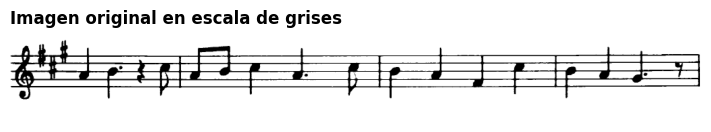

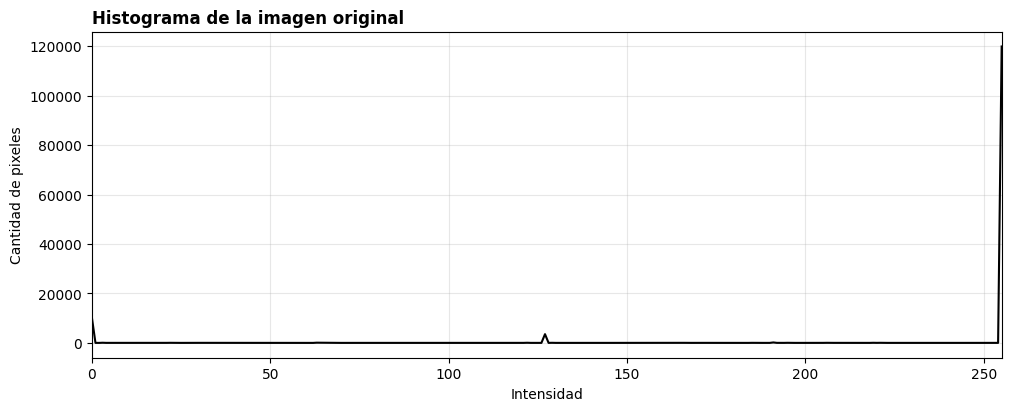

In [ ]:
# Mostramos la imagen original para iniciar el diagnostico.
mostrar_imagen_gris(imagen_notas_gris, "Imagen original en escala de grises")

# Mostramos el histograma para ver como se distribuyen las intensidades.
mostrar_histograma_gris(imagen_notas_gris, "Histograma de la imagen original")


## 2. Umbralizacion global manual

La umbralización es una técnica de procesamiento de imágenes que convierte una imagen, normalmente en escala de grises, en una imagen más simple separando píxeles según su intensidad.
La umbralizacion global obliga a elegir un valor de corte. Todo pixel mas claro o mas oscuro que ese corte cambia de categoria. Ese mecanismo es simple y muy util para pensar el problema, pero no siempre funciona igual de bien en cualquier imagen.
Antes de ejecutar, pensalo asi: si bajas demasiado el umbral, vas a conservar demasiado fondo. Si lo subis demasiado, podes perder trazos finos.

La idea básica es elegir un valor llamado umbral. Luego se compara cada píxel con ese valor:

si intensidad del píxel >= umbral -> blanco
si intensidad del píxel < umbral  -> negro
Por ejemplo, una imagen con fondo oscuro y objetos claros, la umbralización puede ayudar a separar automáticamente los objetos del fondo.

Cómo ayuda en análisis de imágenes

Ayuda principalmente a segmentar, es decir, separar regiones importantes de la imagen. Eso sirve para tareas como:

detectar objetos;

separar texto del fondo;

contar partículas, células, monedas u otros elementos;

medir áreas;

encontrar contornos;

eliminar información irrelevante;

preparar la imagen para otros algoritmos de visión por computadora.

Por ejemplo, si querés analizar una imagen de una hoja con manchas oscuras, podés aplicar umbralización para quedarte solo con las manchas y luego medir cuánta superficie ocupan.

Hay varias formas comunes:

Umbralización global: usa un único umbral para toda la imagen.

Otsu: calcula automáticamente un umbral “óptimo” cuando hay dos grupos claros de intensidades, como objeto y fondo.

Umbralización adaptativa: calcula umbrales locales por zonas, útil cuando la iluminación no es uniforme.

En resumen: la umbralización simplifica la imagen y hace más fácil distinguir lo que te interesa del fondo.


In [ ]:
# Definimos tres cortes distintos para comparar su efecto.
umbral_bajo = 110
umbral_intermedio = 150
umbral_alto = 190

# Aplicamos el primer umbral.
_, mascara_umbral_bajo = cv2.threshold(imagen_notas_gris, umbral_bajo, 255, cv2.THRESH_BINARY_INV)

# Aplicamos el segundo umbral.
_, mascara_umbral_intermedio = cv2.threshold(imagen_notas_gris, umbral_intermedio, 255, cv2.THRESH_BINARY_INV)

# Aplicamos el tercer umbral.
_, mascara_umbral_alto = cv2.threshold(imagen_notas_gris, umbral_alto, 255, cv2.THRESH_BINARY_INV)

# Mostramos las tres mascaras junto con la imagen original.
mostrar_cuatro_imagenes(
    imagen_notas_gris,
    "Original",
    mascara_umbral_bajo,
    f"Umbral manual = {umbral_bajo}",
    mascara_umbral_intermedio,
    f"Umbral manual = {umbral_intermedio}",
    mascara_umbral_alto,
    f"Umbral manual = {umbral_alto}"
)


Fijate que el mecanismo es siempre el mismo, pero el resultado cambia bastante. En una imagen con fondo parejo, un umbral global puede ser suficiente. El problema aparece cuando el fondo no esta bien distribuido o cuando el contraste local cambia mucho.


## 3. Otsu: elegir el corte a partir del histograma

`Otsu` intenta encontrar automaticamente un valor de corte a partir de la distribucion tonal. No es magia: funciona mejor cuando hay cierta separacion entre grupos de intensidades. Muchas veces mejora si antes aplicamos un suavizado leve que reduzca variaciones pequenas.


In [ ]:
# Aplicamos Otsu directamente sobre la imagen original.
umbral_otsu_directo, mascara_otsu_directa = cv2.threshold(
    imagen_notas_gris,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Aplicamos un suavizado gaussiano antes de usar Otsu.
imagen_notas_suavizada = cv2.GaussianBlur(imagen_notas_gris, (5, 5), 0)

# Aplicamos Otsu sobre la imagen suavizada.
umbral_otsu_suavizado, mascara_otsu_suavizada = cv2.threshold(
    imagen_notas_suavizada,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(f"Valor elegido por Otsu sin suavizado: {umbral_otsu_directo:.0f}")
print(f"Valor elegido por Otsu con suavizado: {umbral_otsu_suavizado:.0f}")

# Mostramos la comparacion entre ambas variantes.
mostrar_cuatro_imagenes(
    imagen_notas_gris,
    "Original",
    mascara_otsu_directa,
    "Otsu sin suavizado",
    imagen_notas_suavizada,
    "Suavizado gaussiano",
    mascara_otsu_suavizada,
    "Otsu con suavizado"
)


Aca conviene mirar dos cosas al mismo tiempo: cuanto ruido queda en el fondo y cuanto detalle se pierde en los trazos. `Otsu` puede ser muy util, pero sigue siendo una decision global. Si la iluminacion cambia mucho dentro de la misma imagen, ese unico corte puede quedarse corto.


## 4. Adaptive threshold cuando el fondo no es uniforme

Para que la diferencia se vea mas clara, vamos a construir una version de la imagen con una sombra gradual. Ahi el fondo ya no va a tener una unica referencia tonal y la decision local de `adaptiveThreshold` puede resultar mas adecuada.


In [ ]:
# Creamos una version de la imagen con iluminacion desigual.
imagen_notas_con_sombra = construir_iluminacion_despareja(imagen_notas_gris)

# Aplicamos un umbral global fijo para comparar.
_, mascara_global_con_sombra = cv2.threshold(
    imagen_notas_con_sombra,
    150,
    255,
    cv2.THRESH_BINARY_INV
)

# Aplicamos Otsu sobre la imagen con sombra.
_, mascara_otsu_con_sombra = cv2.threshold(
    imagen_notas_con_sombra,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Aplicamos una version adaptativa basada en vecindarios locales.
mascara_adaptativa_con_sombra = cv2.adaptiveThreshold(
    imagen_notas_con_sombra,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    11
)

# Mostramos la imagen con sombra y las tres salidas principales.
mostrar_cuatro_imagenes(
    imagen_notas_con_sombra,
    "Imagen con iluminacion desigual",
    mascara_global_con_sombra,
    "Umbral global",
    mascara_otsu_con_sombra,
    "Otsu",
    mascara_adaptativa_con_sombra,
    "Adaptive threshold"
)


En esta comparacion suele verse mejor por que `adaptiveThreshold` no debe pensarse como una version "mas fuerte" del umbral global, sino como una estrategia distinta. Su ventaja aparece cuando el fondo no es estable y necesitamos decidir el corte de manera local.


## 5. Ejemplo practico: dejar una mascara lista para limpieza posterior

El objetivo de este paso no es cerrar toda la restauracion, sino preparar una salida razonable para el cuaderno siguiente de morfologia. Aca la mascara resultante ya deberia dejar bastante clara la separacion entre trazos y fondo.


In [ ]:
# Suavizamos la imagen original para reducir pequenas variaciones.
imagen_base_suavizada = cv2.GaussianBlur(imagen_notas_gris, (5, 5), 0)

# Construimos una mascara adaptativa sobre la imagen suavizada.
mascara_lista_para_morfologia = cv2.adaptiveThreshold(
    imagen_base_suavizada,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    11
)

# Mostramos la imagen base y la mascara que podriamos limpiar despues con morfologia.
mostrar_cuatro_imagenes(
    imagen_notas_gris,
    "Imagen original",
    imagen_base_suavizada,
    "Imagen suavizada",
    mascara_lista_para_morfologia,
    "Mascara binaria",
    mascara_lista_para_morfologia,
    "Lista para morfologia"
)


## Actividad breve

Respondé con tus palabras:

1. ¿En que tipo de imagen elegirias un umbral global manual?
Elegiría un umbral global manual cuando la imagen tiene iluminación pareja y el objeto se diferencia claramente del fondo por intensidad. Por ejemplo, texto oscuro sobre una hoja clara bien iluminada.


2. ¿Cuando te parece mas razonable probar `Otsu`?
Probaría Otsu cuando quiero que el programa elija automáticamente el umbral y la imagen parece tener dos grupos de intensidades bastante separados: fondo por un lado y objeto por otro.


3. ¿Que problema especifico intenta resolver `adaptiveThreshold`?
adaptiveThreshold intenta resolver el problema de la iluminación desigual. Sirve cuando una parte de la imagen está más oscura o más clara que otra, porque calcula umbrales locales en vez de usar un único valor para toda la imagen.


4. ¿Por que conviene pensar la binarizacion junto con el paso siguiente de limpieza morfologica?
Conviene pensar la binarización junto con la limpieza morfológica porque la máscara binaria puede quedar con ruido, huecos o bordes irregulares. La morfología ayuda a limpiar esa máscara, pero si la binarización fue muy mala, después es difícil recuperar la información perdida.

## Cierre

Umbralizar no significa solamente transformar una imagen en blanco y negro. Significa decidir como vas a separar informacion relevante de fondo, ruido o iluminacion. Esa decision cambia segun el problema visual. Por eso este cuaderno funciona como puente entre los filtros de suavizado y la morfologia, y tambien como apoyo directo para el `TFI_1` en el caso de medio grafico blanco/negro.
